In [1]:
# ============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# ============================================================================

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys

sys.path.append('../../src')
import accrediff as ad

In [2]:
# ============================================================================
# CELL 2: GLOBAL PARAMETERS & STYLING
# ============================================================================

# ──────────────────────────────────────────────────────
# Nature Style Configuration
# ──────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",        # Serif font
    "font.size": 12,               # Main font size
    "axes.linewidth": 1,           # Axis line width
    "axes.labelsize": 14,          # Axis label size
    "xtick.labelsize": 12,         # X-axis tick font size
    "ytick.labelsize": 12,         # Y-axis tick font size
    "xtick.direction": "in",       # Tick direction inward
    "ytick.direction": "in",
    "xtick.top": False,            # Remove top ticks
    "ytick.right": False,          # Remove right ticks
    "figure.dpi": 300              # High resolution
})

# ──────────────────────────────────────────────────────
# Color Palette
# ──────────────────────────────────────────────────────
Colors = {
    'Earth': "#1f77b4",
    'Mars': "#d62728",
    'IW15': "green",
    'IW35': "purple",
}

# CELL 3: MARKDOWN TITLE

# Source Composition Analysis: Earth-like vs Mars-like Models

Comparative analysis of source material composition (EF, EC, OC, CI) across different collision models 
for Earth-like and Mars-like planetary bodies.

## Core Steps
1. Load multiple simulation data (CSV format)
2. Classify by Class (Earth_like / Mars_like)
3. Calculate statistics (mean, standard deviation)
4. Perform comparative visualization
5. Export results to Excel

In [3]:
# ============================================================================
# CELL 4: DATA LOADING
# ============================================================================

# ============================================================================
# SECTION 1: DATA LOADING - Multiple Simulation Models
# ============================================================================

# Model = 'M03_source'  # ⭐ Adjustable parameter

data_dir = '../Accrection/Tables/'
#data_dir = [os.path.join(base_path, file_name) for file_name in sorted(os.listdir(base_path)) if file_name.endswith('.csv')]
# ── File Existence Check ────────────────────────────────────
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Data directory not found: {data_dir}")

# ── Data Loading ────────────────────────────────────────────
file_paths = [os.path.join(data_dir, file_name) 
              for file_name in sorted(os.listdir(data_dir)) 
              if file_name.endswith('_source.csv')]
keys = [f'sim_{i+1}' for i in range(len(file_paths))]
data_dict = {}

for i, file_path in enumerate(file_paths):
    df = pd.read_csv(file_path, index_col=0)
    data_dict[keys[i]] = df

print(f"✓ Loaded: {data_dir}")
print(f"  Total files: {len(file_paths)}")
print(f"  Model keys : {keys}")
print()

# ── Data Structure Check ────────────────────────────────────
sample_key = keys[0]
sample_df = data_dict[sample_key]

print(f"Sample dataset structure ({sample_key}):")
print(f"  Rows    : {len(sample_df)}")
print(f"  Columns : {list(sample_df.columns)}")

if 'Class' in sample_df.columns:
    class_counts = sample_df['Class'].value_counts()
    print(f"  Classes:")
    for class_type, count in class_counts.items():
        pct = (count / len(sample_df) * 100)
        print(f"    {class_type:15s}: {count:4d} ({pct:5.1f}%)")

print()

✓ Loaded: ../Accrection/Tables/
  Total files: 6
  Model keys : ['sim_1', 'sim_2', 'sim_3', 'sim_4', 'sim_5', 'sim_6']

Sample dataset structure (sim_1):
  Rows    : 2
  Columns : ['a', 'e', 'inc', 'm_e', 'Class', 'B1', 'B2', 'B3', 'EF', 'EC', 'OC', 'CI']
  Classes:
    Earth_like     :    1 ( 50.0%)
    Mars_like      :    1 ( 50.0%)



In [4]:
# ============================================================================
# CELL 5: DATA AGGREGATION
# ============================================================================

# ============================================================================
# SECTION 2: DATA AGGREGATION - Classify Earth-like and Mars-like
# ============================================================================

# ── Initialize Storage Structures ───────────────────────────
earth_like_list = []
mars_like_list = []

print(f"✓ Processing classification:")
print()

# ── Main Loop: Classification by Class ──────────────────────
for sim_key, df in data_dict.items():
    
    # ── Missing Value Check ────────────────────────────────
    if 'Class' not in df.columns:
        print(f"  ⚠️  {sim_key}: Missing 'Class' column - skipped")
        continue
    
    # ── Filter and Add Source Marker ────────────────────────
    df_earth = df[df['Class'] == 'Earth_like'].copy()
    df_mars = df[df['Class'] == 'Mars_like'].copy()
    
    df_earth['model'] = sim_key
    df_mars['model'] = sim_key
    
    earth_like_list.append(df_earth)
    mars_like_list.append(df_mars)
    
    # ── Progress Report ────────────────────────────────────
    n_earth = len(df_earth)
    n_mars = len(df_mars)
    print(f"  {sim_key:10s}: Earth-like {n_earth:4d} | Mars-like {n_mars:4d}")

print()

# ── Result Aggregation ──────────────────────────────────────
earth_like_df = pd.concat(earth_like_list, axis=0, ignore_index=True) if earth_like_list else pd.DataFrame()
mars_like_df = pd.concat(mars_like_list, axis=0, ignore_index=True) if mars_like_list else pd.DataFrame()

print(f"✓ Aggregation complete:")
print(f"  Earth-like total: {len(earth_like_df)} rows")
print(f"  Mars-like total : {len(mars_like_df)} rows")
print()

✓ Processing classification:

  sim_1     : Earth-like    1 | Mars-like    1
  sim_2     : Earth-like    1 | Mars-like    1
  sim_3     : Earth-like    1 | Mars-like    1
  sim_4     : Earth-like    1 | Mars-like    1
  sim_5     : Earth-like    1 | Mars-like    1
  sim_6     : Earth-like    1 | Mars-like    1

✓ Aggregation complete:
  Earth-like total: 6 rows
  Mars-like total : 6 rows



In [5]:
# ============================================================================
# CELL 6: STATISTICAL CALCULATION
# ============================================================================

# ============================================================================
# SECTION 3: STATISTICS - Mean and Standard Deviation
# ============================================================================

# ── Extract Key Columns ────────────────────────────────────
df_Earth = earth_like_df[['EF', 'EC', 'OC', 'CI']].copy()
df_Mars = mars_like_df[['EF', 'EC', 'OC', 'CI']].copy()

# ── Calculate Statistics (Earth-like) ────────────────────
df_Earth.loc['mean'] = df_Earth.mean(numeric_only=True)
df_Earth.loc['std'] = df_Earth.std(ddof=1, numeric_only=True)

# ── Calculate Statistics (Mars-like) ─────────────────────
df_Mars.loc['mean'] = df_Mars.mean(numeric_only=True)
df_Mars.loc['std'] = df_Mars.std(ddof=1, numeric_only=True)

print(f"✓ Statistics calculated")
print(f"  Earth-like: {len(df_Earth)-2} samples + mean/std")
print(f"  Mars-like : {len(df_Mars)-2} samples + mean/std")
print()

# ── Common Columns ─────────────────────────────────────────
common = df_Earth.columns.intersection(df_Mars.columns).tolist()
print(f"  Common columns: {common}")
print()

✓ Statistics calculated
  Earth-like: 6 samples + mean/std
  Mars-like : 6 samples + mean/std

  Common columns: ['EF', 'EC', 'OC', 'CI']



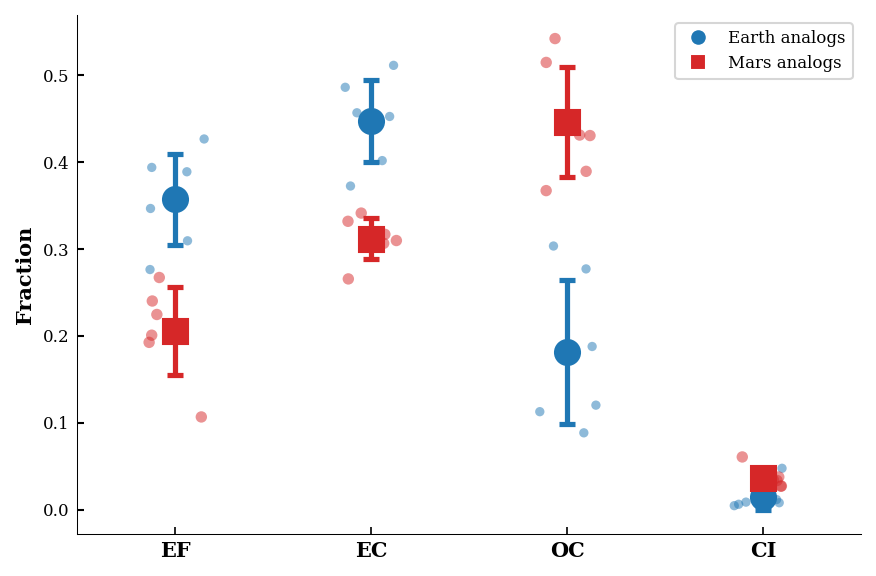

✓ Visualization displayed



In [6]:
# ============================================================================
# CELL 7: VISUALIZATION - Composition Comparison
# ============================================================================

# ============================================================================
# SECTION 4: VISUALIZATION - Earth vs Mars Composition Comparison
# ============================================================================

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

# ── Data Preparation ────────────────────────────────────────
df_Earth_data = df_Earth.drop(['mean', 'std'], errors='ignore')
df_Mars_data = df_Mars.drop(['mean', 'std'], errors='ignore')

rng = np.random.default_rng(42)
x = np.arange(len(common))

# ── Earth-like Scatter Plot ────────────────────────────────
for i, col in enumerate(common):
    jitter = rng.choice([-1, 1], size=len(df_Earth_data)) * rng.uniform(0.05, 0.15, len(df_Earth_data))
    ax.scatter(np.full(len(df_Earth_data), i) + jitter, 
               df_Earth_data[col], 
               color=Colors['Earth'], alpha=0.5, s=20, zorder=1, edgecolors='none')

# ── Mars-like Scatter Plot ──────────────────────────────────
for i, col in enumerate(common):
    jitter = rng.choice([-1, 1], size=len(df_Mars_data)) * rng.uniform(0.05, 0.15, len(df_Mars_data))
    ax.scatter(np.full(len(df_Mars_data), i) + jitter, 
               df_Mars_data[col], 
               color=Colors['Mars'], alpha=0.5, s=30, zorder=1, edgecolors='none')

# ── Earth-like Mean ± Standard Deviation ─────────────────────
ax.errorbar(x, df_Earth.loc['mean', common], yerr=df_Earth.loc['std', common], 
            fmt='o', color=Colors['Earth'], markersize=12, 
            capsize=4, capthick=2.5, elinewidth=2.5, zorder=3, label='Earth analogs')

# ── Mars-like Mean ± Standard Deviation ──────────────────────
ax.errorbar(x, df_Mars.loc['mean', common], yerr=df_Mars.loc['std', common], 
            fmt='s', color=Colors['Mars'], markersize=12, 
            capsize=4, capthick=2.5, elinewidth=2.5, zorder=3, label='Mars analogs')

# ── Style Beautification ────────────────────────────────────
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# ── Axis Labels ────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(['EF', 'EC', 'OC', 'CI'], fontweight='bold', fontsize=10)
ax.set_ylabel('Fraction', fontsize=10, fontweight='bold')
ax.set_xlim(-0.5, len(common) - 0.5)
ax.tick_params(axis='y', labelsize=8, width=1)

# ── Legend ──────────────────────────────────────────────────
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Earth analogs',
               markerfacecolor=Colors['Earth'], markersize=8),
    plt.Line2D([0], [0], marker='s', color='w', label='Mars analogs',
               markerfacecolor=Colors['Mars'], markersize=8),
]
ax.legend(handles=legend_handles, fontsize=8, loc='best', frameon=True)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"✓ Visualization displayed")
print()